# Residency-5: Project-1 | Featurization_Model_Selection_and_Tuning | Jayant Ojha

## Problem statement

### Dataset
Predict House Prices

data set :-kc_house_data.csv.zip

Dataset Info –

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

19 house features plus the price and the id columns, along with 21613 observations.


**Attributes of the dataset:**

Attribute Information:

id - a notation for a house

date -Date house was sold

price- Price is prediction target

bedrooms- Number of Bedrooms/House

bathrooms- Number of bathrooms/bedrooms

sqft_living- square footage of the home

sqft_lot- square footage of the lot

floors-Total floors (levels) in house

waterfront- House which has a view to a waterfront

view-Has been viewed

condition-How good the condition is ( Overall )

grade-overall grade given to the housing unit, based on King County grading system

sqft_above-square footage of house apart from basement

sqft_basement-square footage of the basement

yr_built-Built Year

yr_renovated-Year when house was renovated

zipcode-zip

lat-Latitude coordinate

long-Longitude coordinate

sqft_living15-Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area-

sqft_lot15

lotSize area in 2015(implies-- some renovations)


## Step 1

Import libraries and read the dataset.

In [335]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [336]:
import pathlib as pth
import shutil
from os import path, unlink, listdir
import numpy as np
import pandas as pd
from matplotlib import pyplot
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import math
import warnings 
warnings.filterwarnings('ignore')

In [337]:
# Root directory for the project
PRJ_ROOT_DIR = r"{}\\".format(pth.Path.cwd())
# Data-Set path (assuming, data set will be @ the "data" folder
# under a project root.
DATA_SET_PATH = r"{}\\data\\".format(PRJ_ROOT_DIR)
DATA_SET_CSV_PATH = r"{}\data\kc_house_data.csv".format(PRJ_ROOT_DIR)
DATA_SET_XLS_PATH = r"{}\data\\".format(PRJ_ROOT_DIR)
PLOT_PATH = r"{}\\plots\\".format(PRJ_ROOT_DIR)
DBG_FILES = True
IPYNB_ENV = True

In [338]:
def read_data_set(data_path):
    """
    Read the csv or excel file at a given path, into a dataframe & return the same
    :param data_path:
    :return:
    """
    if data_path == DATA_SET_XLS_PATH:
        df = pd.read_excel(data_path, encoding="ISO-8859-1")
    else:
        df = pd.read_csv(DATA_SET_CSV_PATH, encoding="ISO-8859-1")
    col_name_full = list(df.columns)
    return df.loc[:, col_name_full]

In [339]:
df = read_data_set(DATA_SET_CSV_PATH)
df.shape
df.sample(n=5, random_state=7)
df.describe(include='all').T

(21613, 21)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
18732,1944900090,20140519T000000,462000.0,5,1.75,1250,10530,1.0,0,0,...,7,1250,0,1966,0,98007,47.6101,-122.138,1560,8190
18573,2597520900,20140804T000000,768000.0,3,2.50,2660,10928,2.0,0,0,...,9,1830,830,1988,0,98006,47.5442,-122.141,2800,10025
11401,4141800030,20141014T000000,920000.0,3,1.75,2480,4000,1.0,0,0,...,8,1240,1240,1948,2014,98122,47.6150,-122.288,2450,4000
19712,301400830,20141223T000000,263000.0,3,2.50,1584,3200,2.0,0,0,...,7,1584,0,2011,0,98002,47.3451,-122.215,1584,2800
17921,1776230180,20141008T000000,427500.0,4,2.50,2430,3249,2.0,0,0,...,8,2430,0,2010,0,98059,47.5048,-122.155,2650,3844


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613,NaN,NaN,NaN,4.5803e+09,2.87657e+09,1.0001e+06,2.12305e+09,3.90493e+09,7.3089e+09,9.9e+09
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613,NaN,NaN,NaN,540088,367127,75000,321950,450000,645000,7.7e+06
bedrooms,21613,NaN,NaN,NaN,3.37084,0.930062,0,3,3,4,33
bathrooms,21613,NaN,NaN,NaN,2.11476,0.770163,0,1.75,2.25,2.5,8
sqft_living,21613,NaN,NaN,NaN,2079.9,918.441,290,1427,1910,2550,13540
sqft_lot,21613,NaN,NaN,NaN,15107,41420.5,520,5040,7618,10688,1.65136e+06
floors,21613,NaN,NaN,NaN,1.49431,0.539989,1,1,1.5,2,3.5
waterfront,21613,NaN,NaN,NaN,0.00754176,0.0865172,0,0,0,0,1
view,21613,NaN,NaN,NaN,0.234303,0.766318,0,0,0,0,4


In [340]:
def quant_attrib_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20, clean_current=False, file_postfix=None):
    """
    The following function is being written to plot the "individual" & "detailed" spread of the histogram for only the
    quantitative features alone.Here, the default "cut-points" value is 40. All the "quantitative" features alone(which
    actually are, all of them, for the sample data above) are selected by using the "describe" data-frame.Then it loops
    through individual features, and the feature-min to feature-max is divided into the cut-points (default 40)& plotted
    in turn. Many of the features may show outliers (on a z-score, seen separately using the commented line, with
    "normed" option below with up to  z= +3.0 & beyond)
    :param clean_current:
    :param file_postfix:
    :param df:
    :param cut_pts:
    :param fig_height:
    :param fig_len:
    """
    descr_df = df.describe().loc[['min', 'max'], :]  # , 'count', 'mean', 'std']
    if clean_current:
        remove_files(PLOT_PATH)
    if DBG_FILES:
        print("*********************************************************************************")
    for feature in list(descr_df.T.index):
        bins = np.linspace(descr_df[feature]['min'], descr_df[feature]['max'], cut_pts)
        pyplot.subplots(figsize=(fig_len, fig_height))
        # pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature))
        pyplot.hist(df[feature], bins, alpha=0.5, label=str(feature))
        pyplot.legend(loc='upper right')
        if not IPYNB_ENV:
            fname = PLOT_PATH + "{0}_{1}.png".format(feature, file_postfix)
            pyplot.savefig(fname)
            if path.exists(fname):
                if DBG_FILES:
                    print(path.abspath(fname))
            else:
                print("file not found")
            pyplot.close(pyplot.gcf())
        else:
            #%matplotlib inline
            pyplot.show()
    if DBG_FILES:
        print("*********************************************************************************")


def get_all_num_cols(df, verbose=False):
    """
    This routine returns the list of all numeric columns, in a pandas dataframe.This list is a possible mix of both
    null & non-null columns
    :param verbose:
    :param df:
    :return: list
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if verbose:
        print("*********************************************************************************")
        print("The list of all NUMERIC-COLUMNS is {}".format(num_cols))
        print("*********************************************************************************")
    return num_cols


def get_null_num_cols(df, verbose=False):
    """
    This routine returns the list of all null-numeric columns, in a pandas dataframe.This list only has the null
    numeric columns.
    :param verbose:
    :param df:
    :return: list
    """
    null_num_cols = [x for x in get_all_num_cols(df) if df[x].isnull().any()]
    if verbose:
        print("*********************************************************************************")
        print("The list of all **NULL** NUMERIC-COLUMNS is {}".format(null_num_cols))
        print("*********************************************************************************")
    return null_num_cols


def get_all_non_num_cols(df, verbose=False):
    """
    This routine returns the list of all non-numeric columns, in a pandas dataframe.This list is a possible mix of both
    null & non-null columns
    :param verbose:
    :param df:
    :return: list
    """
    non_num_cols = [x for x in list(df.columns) if x not in get_all_num_cols(df)]
    if verbose:
        print("*********************************************************************************")
        print("The list of all NON-NUMERIC-(OBJECT-TYPE)-COLUMNS is {}".format(non_num_cols))
        print("*********************************************************************************")
    return non_num_cols



def get_null_non_num_cols(df, verbose=False):
    """
    This routine returns the list of all null-non-numeric columns, in a pandas dataframe.This list just has the
    "object" columns which have some potential null values
    :param verbose:
    :param df:
    :return: list
    """
    null_non_num_cols = [x for x in get_all_non_num_cols(df) if pd.to_numeric(df[x], errors='coerce').isnull().any()]
    tmp_df = df.copy()
    if verbose:
        print("*********************************************************************************")
    for col in null_non_num_cols:
        tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
        x = tmp_df[[col]].describe(include='all').loc['mean', col]
        if math.isnan(x):
            if verbose:
                print(f"The NON-NUMERIC-(OBJECT-TYPE)-COLUMN:'{col}'' is a FULL-FLEDGED OBJECT-TYPE")
                print("       **This col:'{}' will require a different treatment**    ".format(col))
            null_non_num_cols.remove(col)
    if verbose:
        print("*********************************************************************************")
        print("*********************************************************************************")
        print("The list of all **NULL** NON-NUMERIC-(OBJECT-TYPE)-COLUMNS is {}".format(null_non_num_cols))
        print("*********************************************************************************")
    return null_non_num_cols



def display_rows_null_num_cols(df):
    """
    This routine prints out the rows, w.r.t. the null-numeric column (one at a time)
    :param df:
    :return: list
    """
    for col in get_null_num_cols(df):
        print("*********************************************************************************")
        print("Following dataframe rows has NULL values, for the NUMERIC column: {}".format(col))
        print("*********************************************************************************")
        print(df[pd.to_numeric(df[col]).isnull()])


def display_rows_null_non_num_cols(df):
    """
    This routine prints out the rows, w.r.t. the null-non-numeric column (one at a time)
    :param df:
    :return: list
    """
    for col in get_null_non_num_cols(df):
        print("*********************************************************************************")
        print("Following dataframe rows has NULL values, for the NON-NUMERIC column: {}".format(col))
        print("*********************************************************************************")
        print(df[pd.to_numeric(df[col], errors='coerce').isnull()])


def impute_rows_null_cols(df, fill_opt_dict, clean_current=False, compare_dist=True):
    """
    This routine fills and/or drop out the rows, w.r.t. the null-numeric column (one at a time) & based-on a
    user-supplied dict of options, feature-wise.
    :param clean_current:
    :param compare_dist:
    :param fill_opt_dict:
    :param df:
    :return: list
    """
    if clean_current:
        remove_files(PLOT_PATH)
    for col in fill_opt_dict.keys():
        numeric_feature = col in get_all_num_cols(df)
        object_feature = col in get_all_non_num_cols(df)
        assert numeric_feature != object_feature
        if col not in list(df.columns):
            print("*********************************************************************************")
            print("The Fill-Option-Dict you passed, doesn't match the dataframe column @ {}".format(col))
            print("*********************************************************************************")
            assert 0
        else:
            if numeric_feature:
                print("*********************************************************************************")
                print(f"For NULL-NUMERIC column: {col}, the user-provided IMPUTE-option is: {fill_opt_dict[col]}")
                print("*********************************************************************************")
                df_slice_ref = df[pd.to_numeric(df[col]).isnull()]
            elif object_feature:
                print("*********************************************************************************")
                print(f"For NULL-NON-NUMERIC(OBJECT-TYPE)column:{col},user-provided IMPUTE-option:{fill_opt_dict[col]}")
                print("*********************************************************************************")
                df_slice_ref = df[pd.to_numeric(df[col], errors='coerce').isnull()]
                df[col] = df[[col]].apply(pd.to_numeric, errors='coerce')
            else:
                assert 0
            _fill_user_value(df, col, df_slice_ref, fill_opt_dict[col], compare_dist)
            df.to_csv(DATA_SET_PATH + 'tmp.csv', na_rep='NaN', index=False, quoting=3)


def _fill_user_value(df, col, df_slice_ref, usr_opt, compare_dist):
    """
    This is a helper routine (used by the user-accessed "impute_rows_null_num_cols" to fill user values.Iteratively
    use it(thru "impute_rows_null_num_cols") to get a visual-guidance on the impact of imputation. Based on the user
    decision, after having visualized the impact of any such imputations.
    :param compare_dist:
    :param df_slice_ref:
    :param df:
    :param col:
    :param df_slice_ref:
    :param usr_opt:
    """
    if compare_dist and usr_opt != 'drop':
        quant_attrib_hist_plot(df[[col]], file_postfix="_dist_before_{}_impute_of_{}".format(usr_opt, col))
    elif compare_dist and usr_opt == 'drop':
        quant_attrib_hist_plot(df, file_postfix="_dist_before_{}_impute_of_{}".format(usr_opt, col))
    if usr_opt == 'mean':
        df[col].fillna(round(df[col].mean(), 2), inplace=True)
    elif usr_opt == 'median':
        df[col].fillna(round(df[col].median(), 2), inplace=True)
    elif usr_opt == 'drop':
        df.drop(df_slice_ref.index, inplace=True)
    else:
        # assert (str.type != float)
        df[col].fillna(round(usr_opt, 2), inplace=True)
    if compare_dist and usr_opt != 'drop':
        quant_attrib_hist_plot(df[[col]], file_postfix="_dist_after_{}_impute_of_{}".format(usr_opt, col))
    elif compare_dist and usr_opt == 'drop':
        quant_attrib_hist_plot(df, file_postfix="_dist_after_{}_impute_of_{}".format(usr_opt, col))



def remove_files(files_at_path):
    """
    Simple utility to delete files and sub-folders at a given path.
    :param files_at_path:
    """
    for the_file in listdir(files_at_path):
        file_path = path.join(files_at_path, the_file)
        try:
            if path.isfile(file_path):
                unlink(file_path)
            elif path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(e)


def get_data_null_nonnull_summary():
    """
    Give a quick summary of null & non-null elements.Show each row for those features.
    """
    df = read_data_set(DATA_SET_CSV_PATH)
    get_all_num_cols(df, True)
    get_all_non_num_cols(df, True)
    get_null_non_num_cols(df, True)
    get_null_num_cols(df, True)
    display_rows_null_num_cols(df)
    display_rows_null_non_num_cols(df)
    print("*********************************************************************************")
    print("                ***If any NULL entries were found***")
    print("You can now use: <impute_rows_null_cols> routine to guide you through imputation")
    print("*********************************************************************************")
    
    
    
def select_features(df, user_exclude_list):
    """
    Select the features by providing the dataframe & a list_to_drop feature-set.
    :param user_exclude_list:
    :param df:
    :return:
    """
    return [x for x in list(df.columns) if x not in user_exclude_list]


def plot_correlation_heatmap(df, user_exclude_list):
    """
    Plot the correlation-heatmap for the passed dataframe, while REMOVING the features in the
    "list_to_drop' parameter.
    :param user_exclude_list:
    :param df:
    """
    features = select_features(df, user_exclude_list)
    mask = np.zeros_like(df[features].corr(), dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    pyplot.subplots(figsize=(15, 10))
    pyplot.title('Pearson Correlation Matrix', fontsize=25)
    sns.heatmap(df[features].corr(), annot=True, linewidths=0.25, vmax=0.7, square=True, linecolor='w',
                annot_kws={"size": 8}, mask=mask, cbar_kws={"shrink": .9})
    
    

def get_sorted_corr_list(df, dep_var, user_exclude_list, ascending=False):
    """
    Routine to return a list of sorted-absolute-correlation values of feature-set w.r.t. the dependent variable.
    :param df:
    :param dep_var:
    :param user_exclude_list:
    :param ascending:
    :return:
    """
    features = select_features(df, user_exclude_list)
    cor = df[features].corr()
    # Correlation with dependent variable
    cor_target = abs(cor[dep_var])
    lst = list(cor_target.sort_values(ascending=ascending).index.values)
    lst.remove(dep_var)
    return lst


    
def plot_pairplot(df, user_exclude_list):
    """
    Plot the pair-plot for the passed dataframe, while REMOVING the features in the
    "list_to_drop' parameter.
    :param user_exclude_list:
    :param df:
    """
    features = select_features(df, user_exclude_list)
    sns.pairplot(df[features],diag_kind='kde')



def get_p_value_feature_drop_list(df, dep_var, user_exclude_list, alpha=0.05, show_summary=True):
    """
    Return the feature-list, which show a p-value> alpha (0.05, default). This list of features fail to reject the
    null hypothesis & hence first direct candidates for removal.
    :param show_summary:
    :param df:
    :param dep_var:
    :param user_exclude_list:
    :param alpha:
    """
    features = select_features(df, user_exclude_list)
    str1 = "+".join(features)
    str1 = dep_var + '~' + str1
    model = smf.ols(str1, df).fit()
    mdl_smry = model.summary()
    results_as_html = mdl_smry.tables[1].as_html()
    df_tmp = pd.read_html(results_as_html, header=0, index_col=0)[0]
    if show_summary:
        print(mdl_smry)
    return list(df_tmp.loc[df_tmp["P>|t|"] > alpha].index)


def adjustedR2(r2,n,k):
    return r2-(k-1)/(n-k)*(1-r2)


## Step 2

Explore Data Analysis. Find out how one variable related to other and distributions of data.

## Step 3

Based on Above, State your insights.

In [341]:
#Is any data-imputation required?
get_data_null_nonnull_summary()

*********************************************************************************
The list of all NUMERIC-COLUMNS is ['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
*********************************************************************************
*********************************************************************************
The list of all NON-NUMERIC-(OBJECT-TYPE)-COLUMNS is ['date']
*********************************************************************************
*********************************************************************************
The NON-NUMERIC-(OBJECT-TYPE)-COLUMN:'date'' is a FULL-FLEDGED OBJECT-TYPE
       **This col:'date' will require a different treatment**    
*********************************************************************************
********************************

In [342]:
#Out of above, one feature which immediately rings a bell: 'zipcode'.Convert it to
#'object' type to see its "frequency" and other characteristics.
df['zp'] = df['zipcode'].astype(object)
df[['zp']].describe(include='all')

,zp
count,21613
unique,70
top,98103
freq,602


* The 'zipcode feature has 70 unique values, we will give a look at its "numeric" distribution as well, as shown in the next step, along with other features.

*********************************************************************************


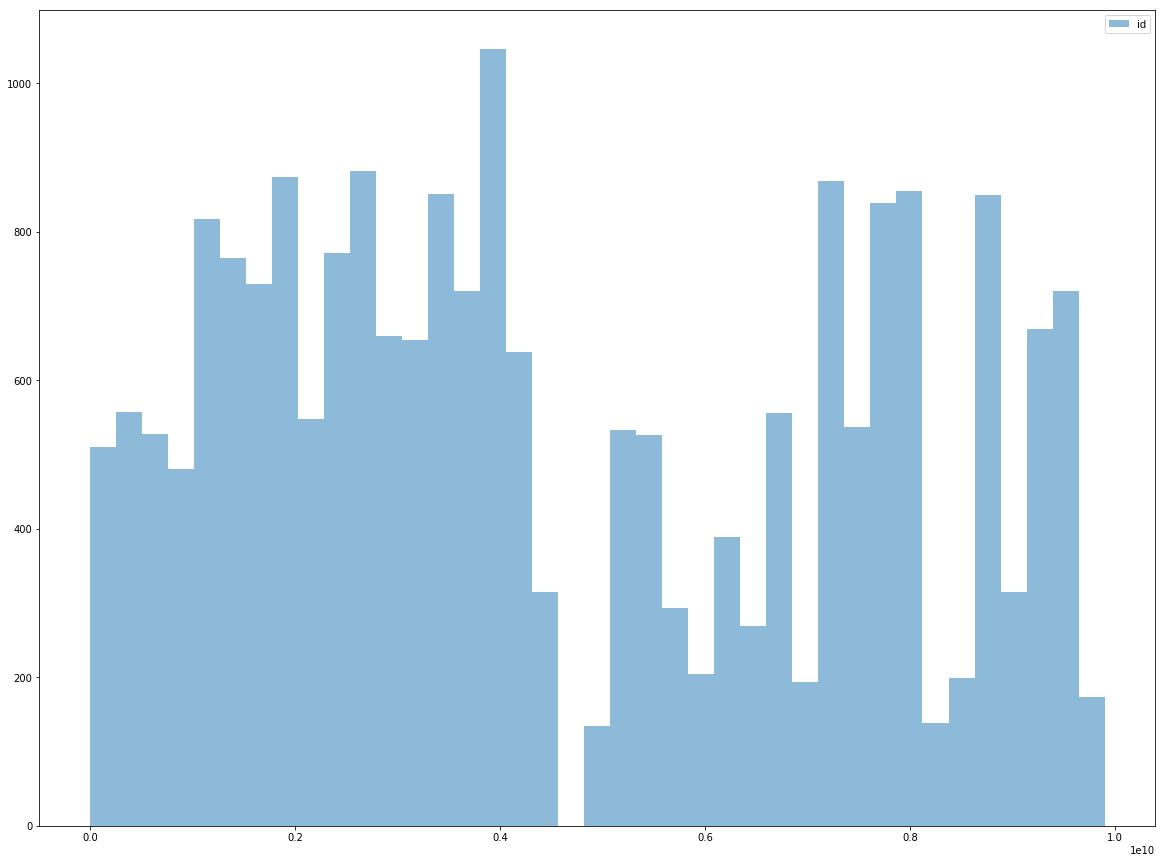

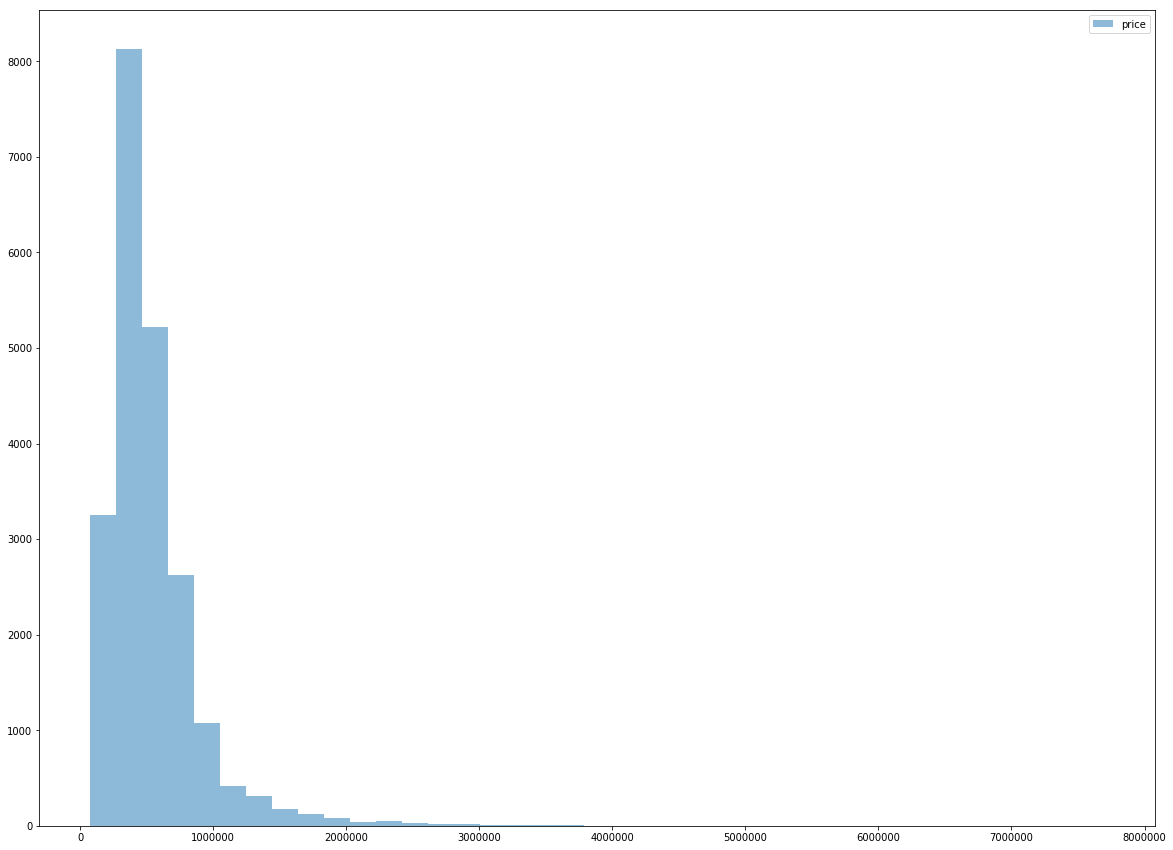

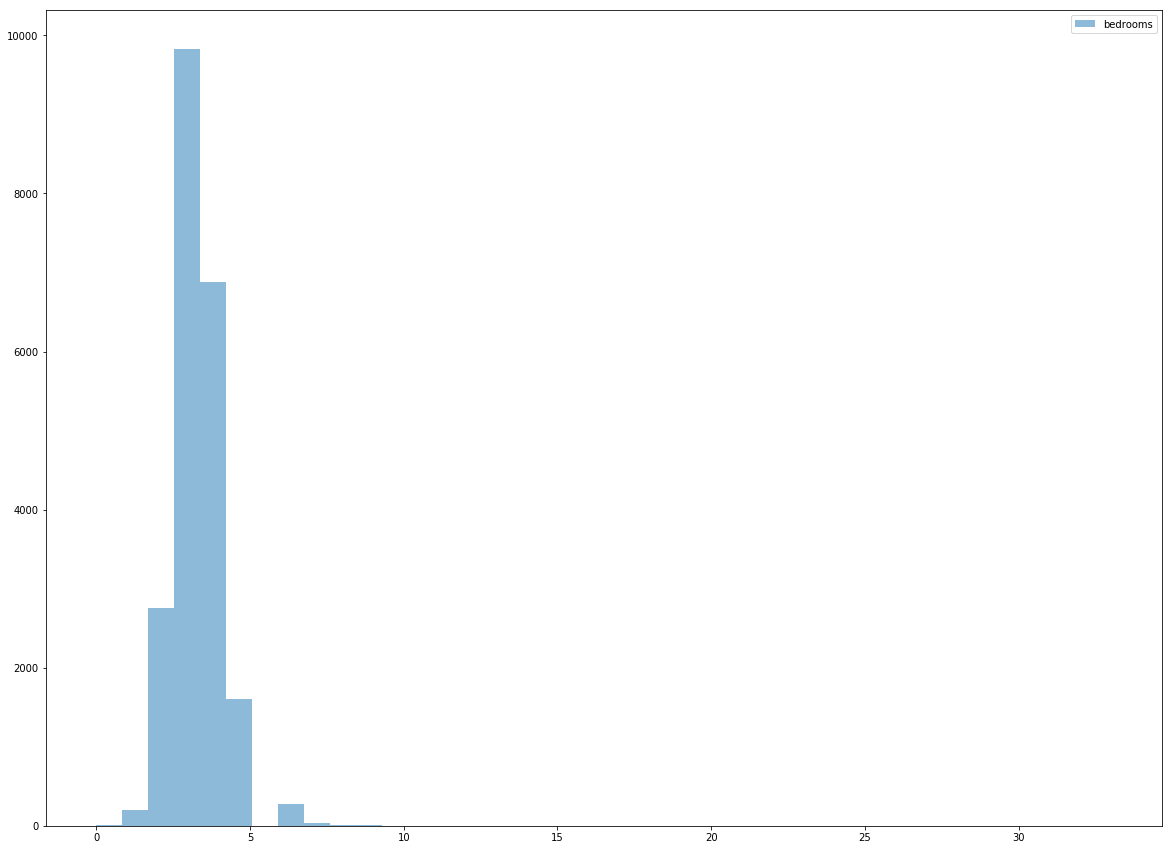

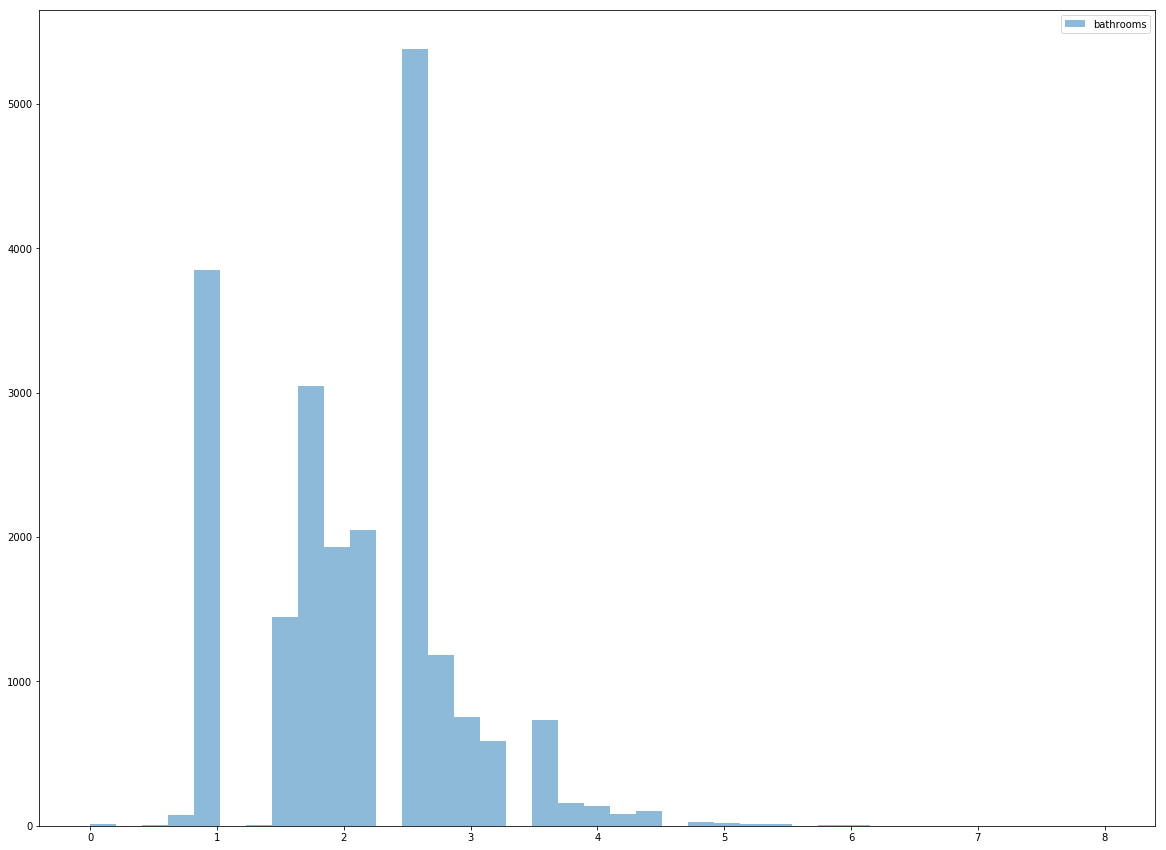

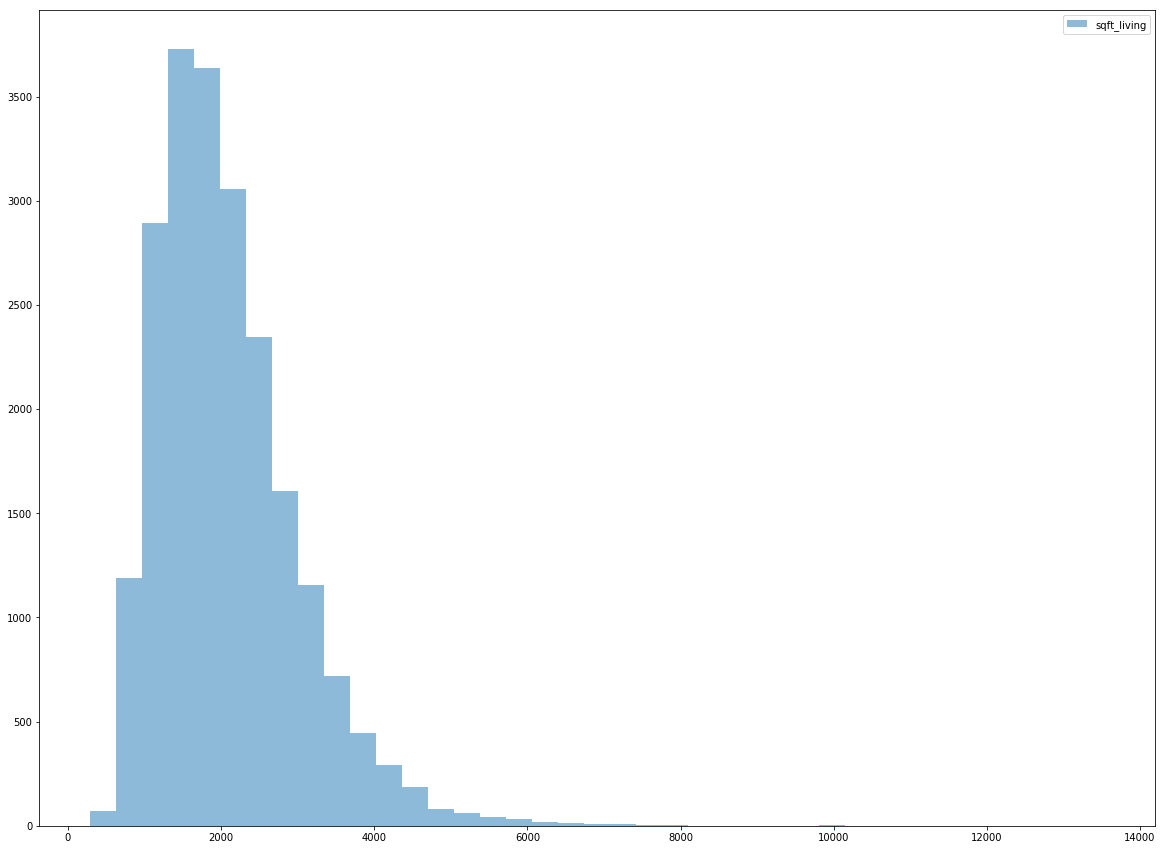

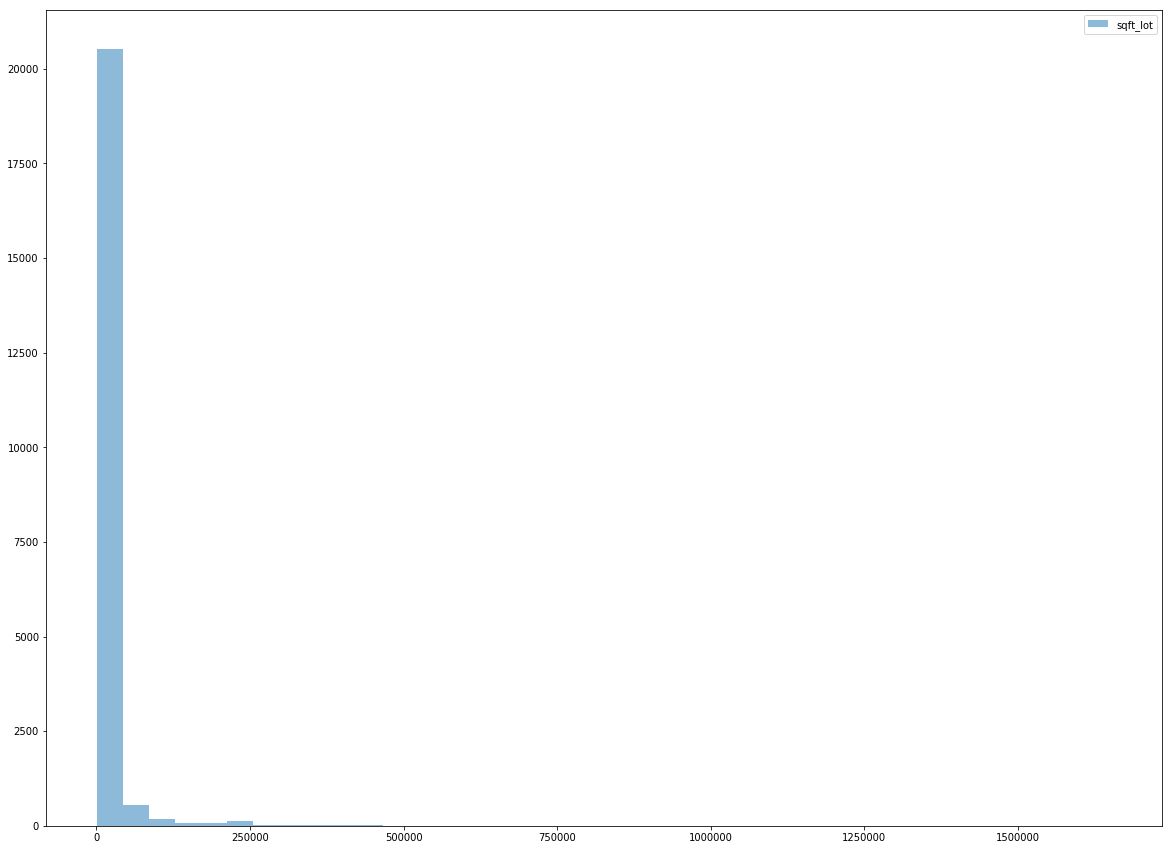

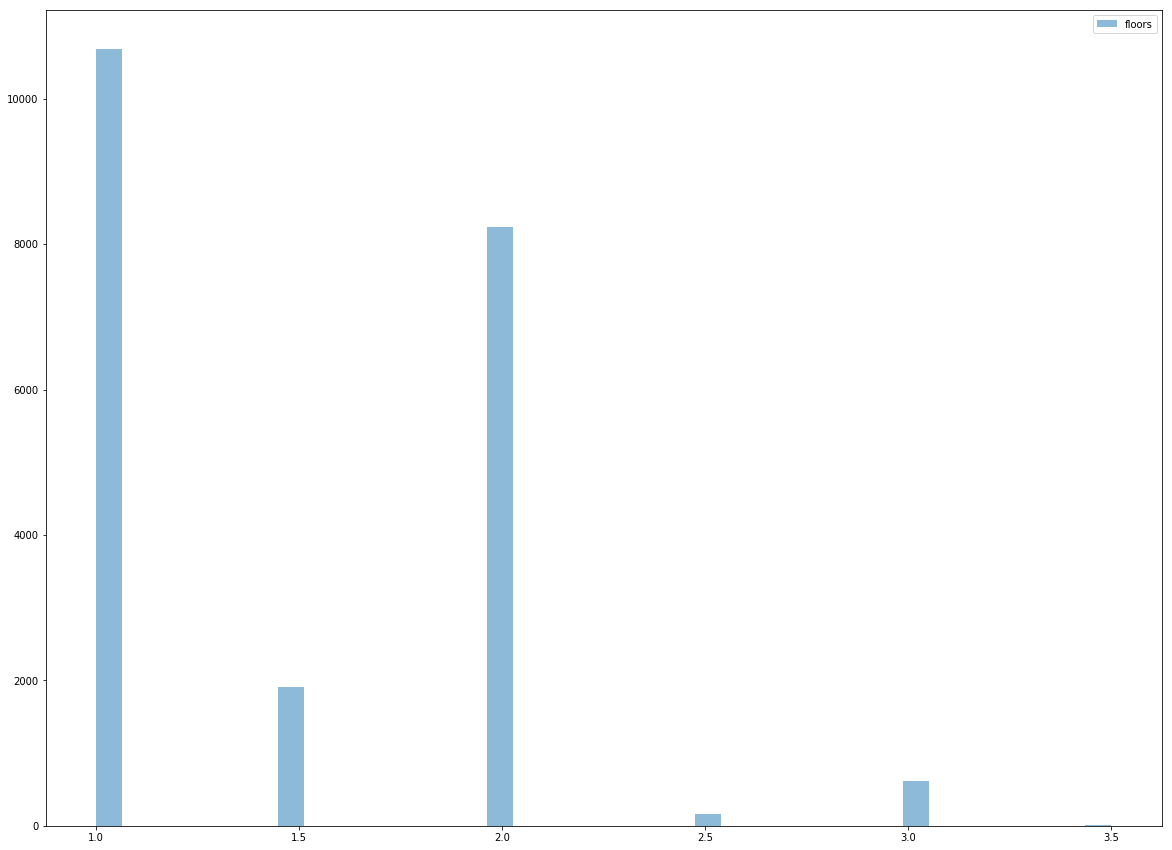

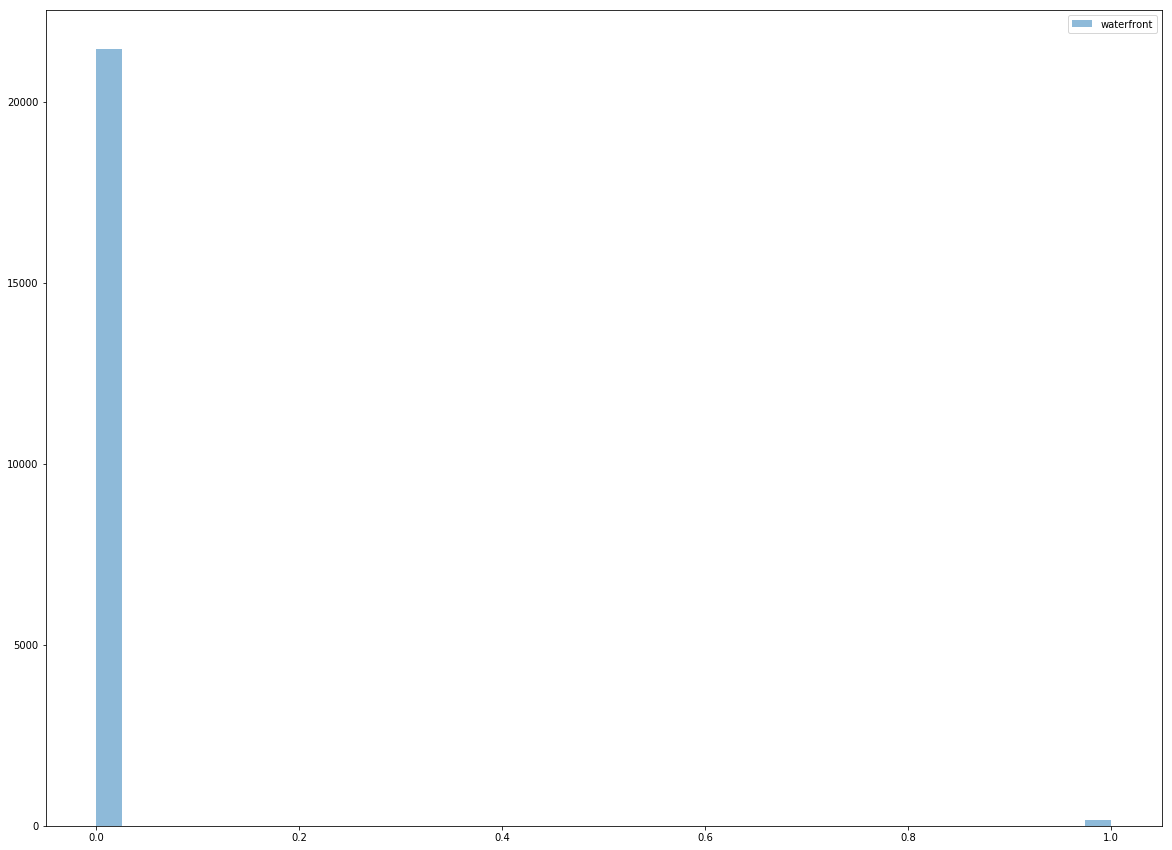

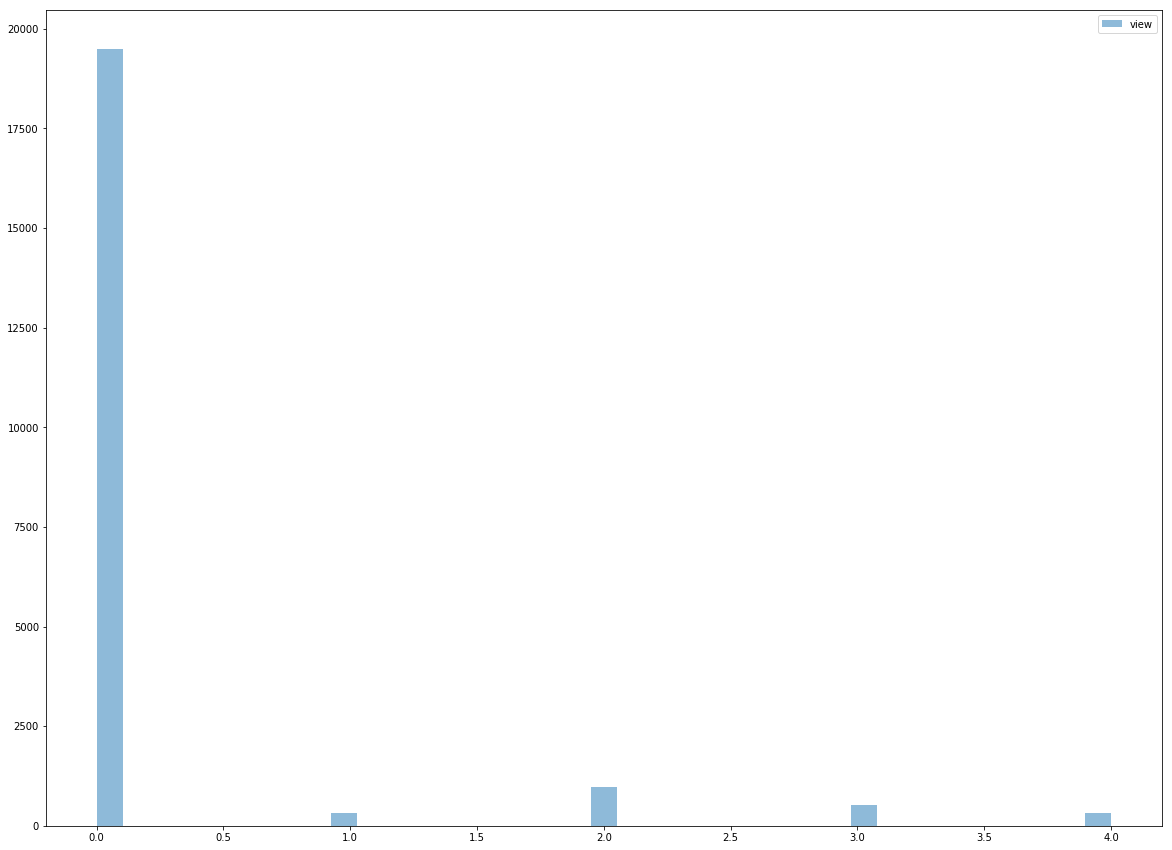

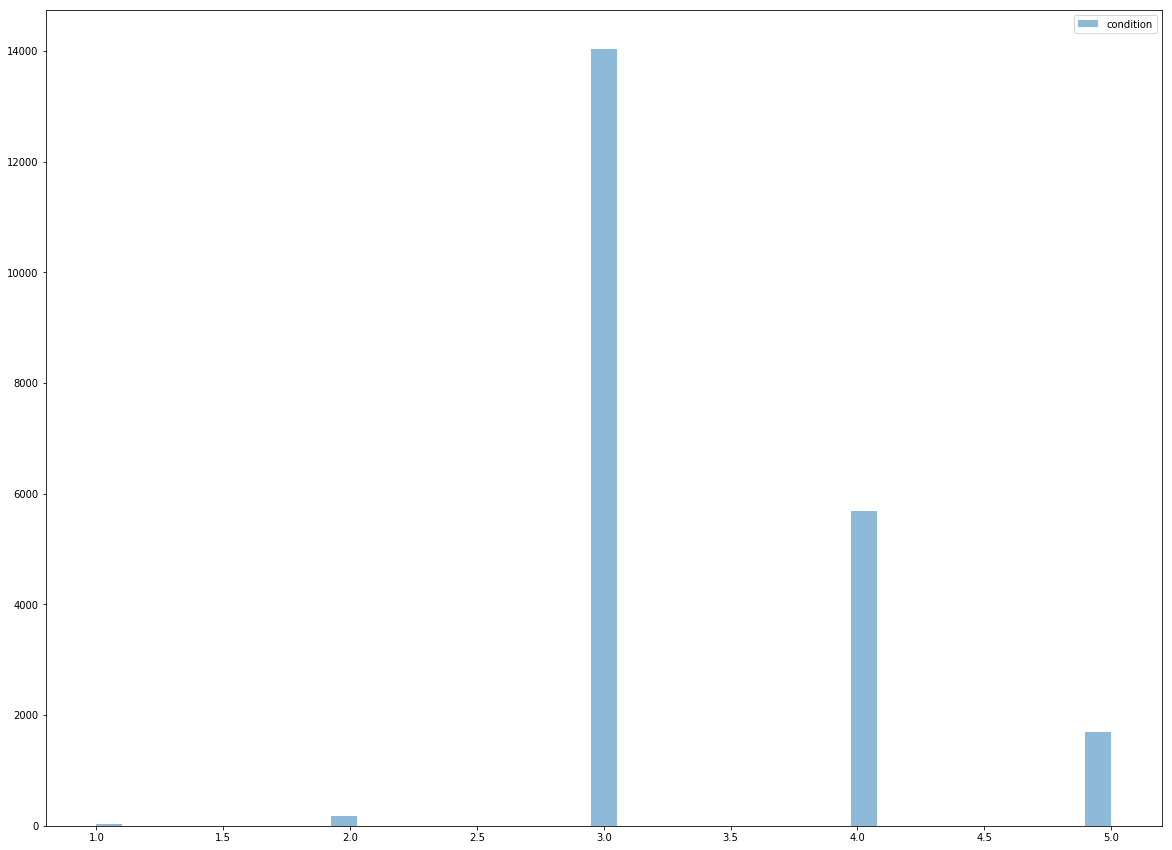

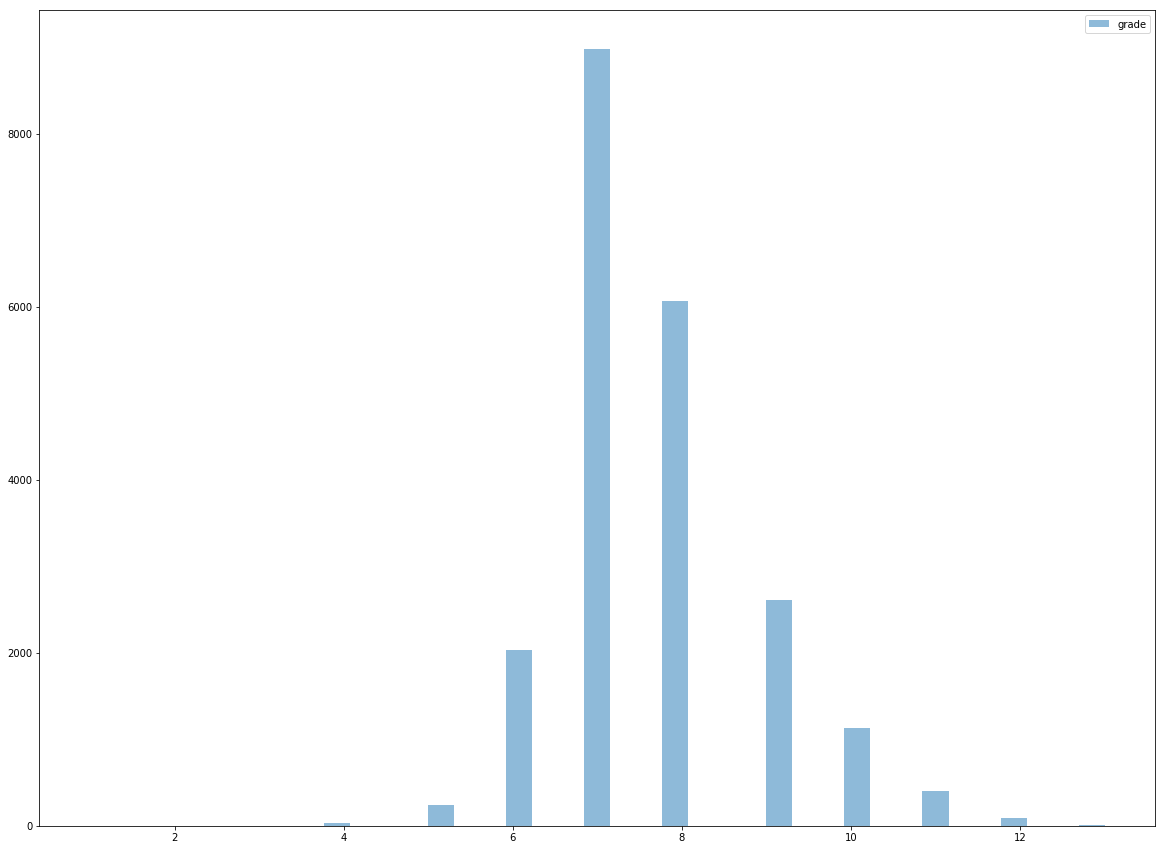

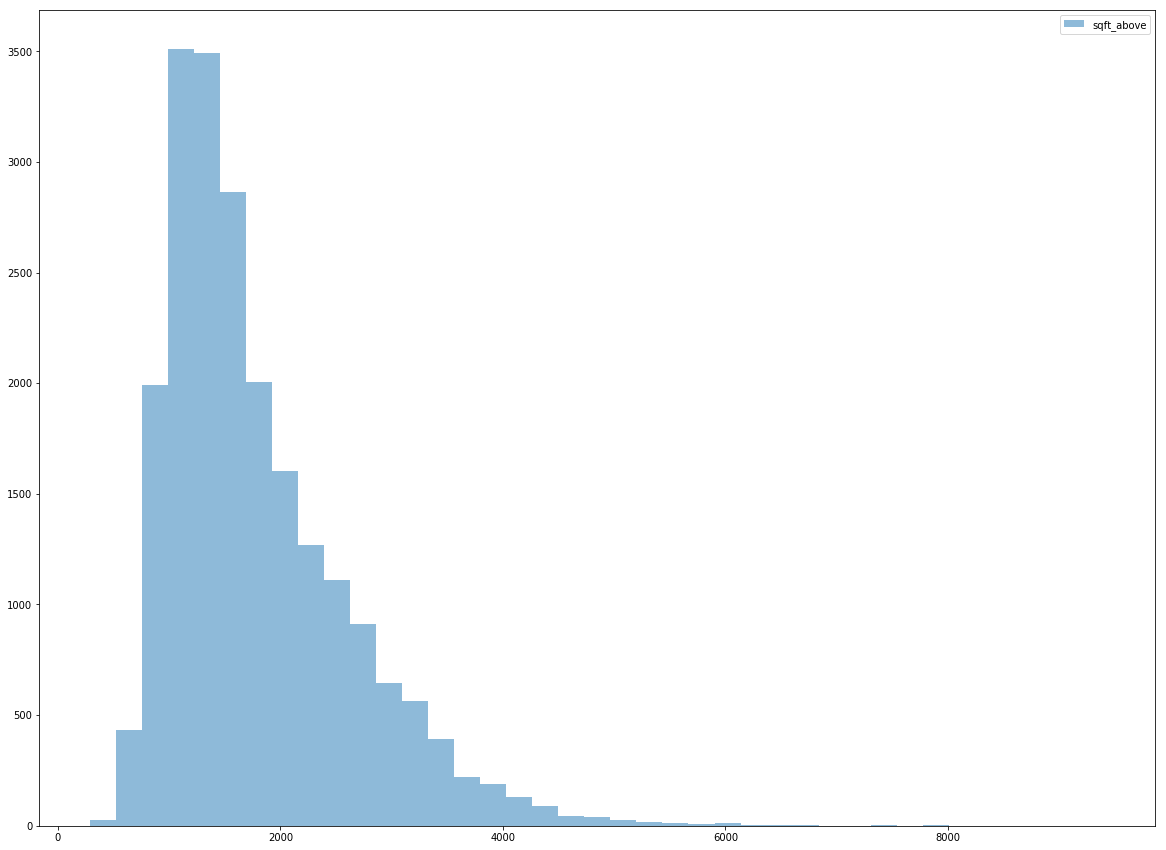

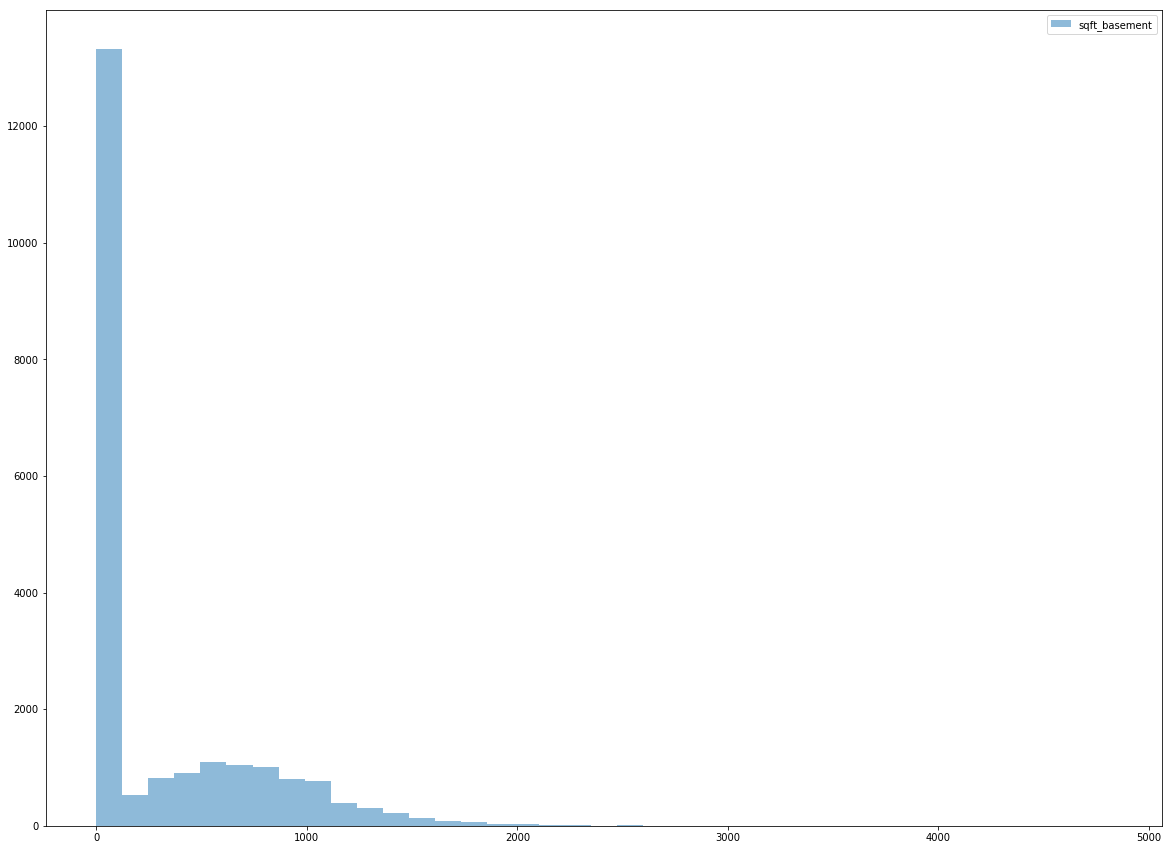

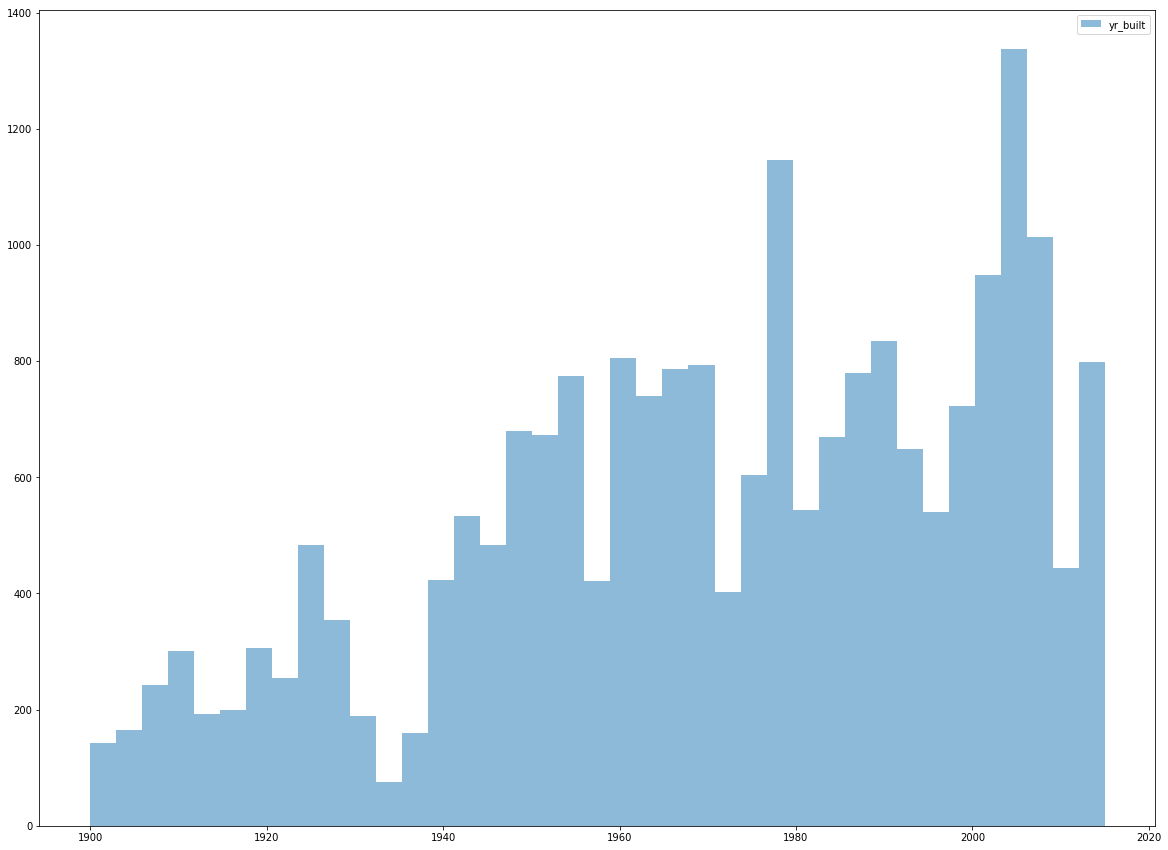

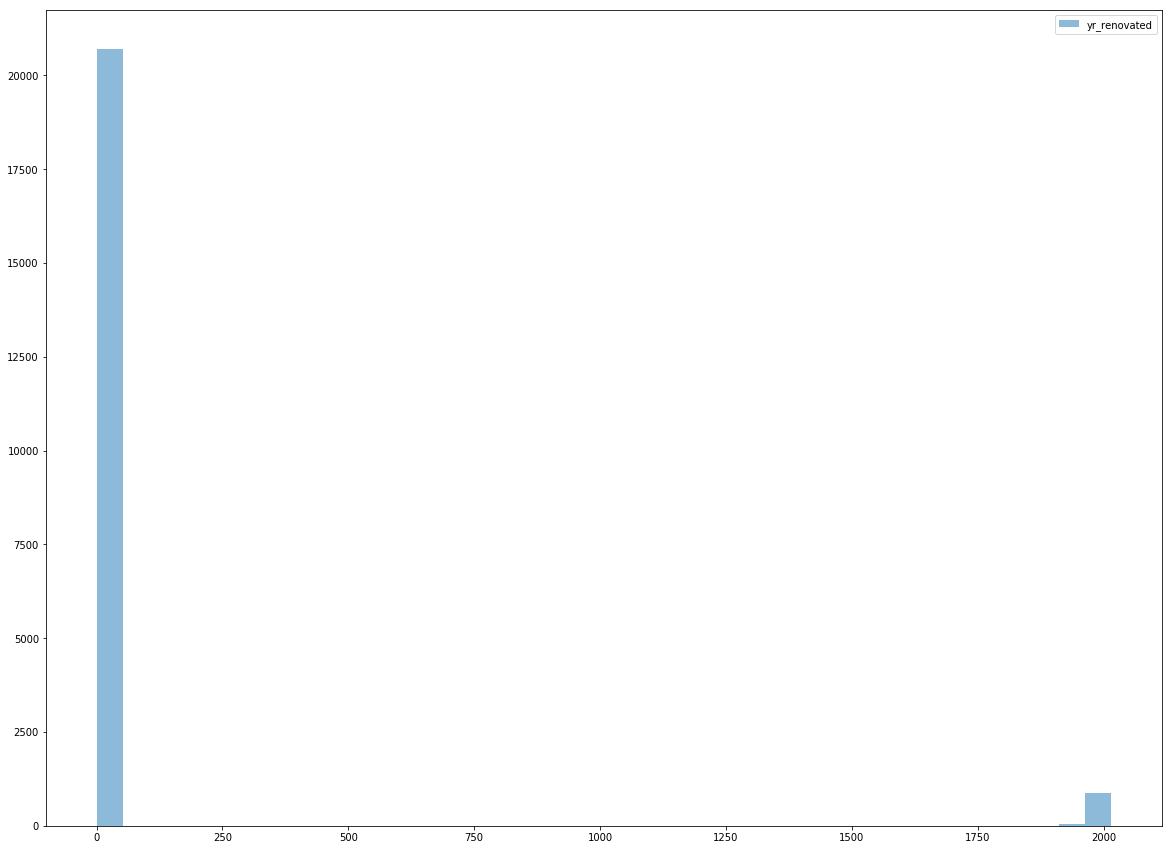

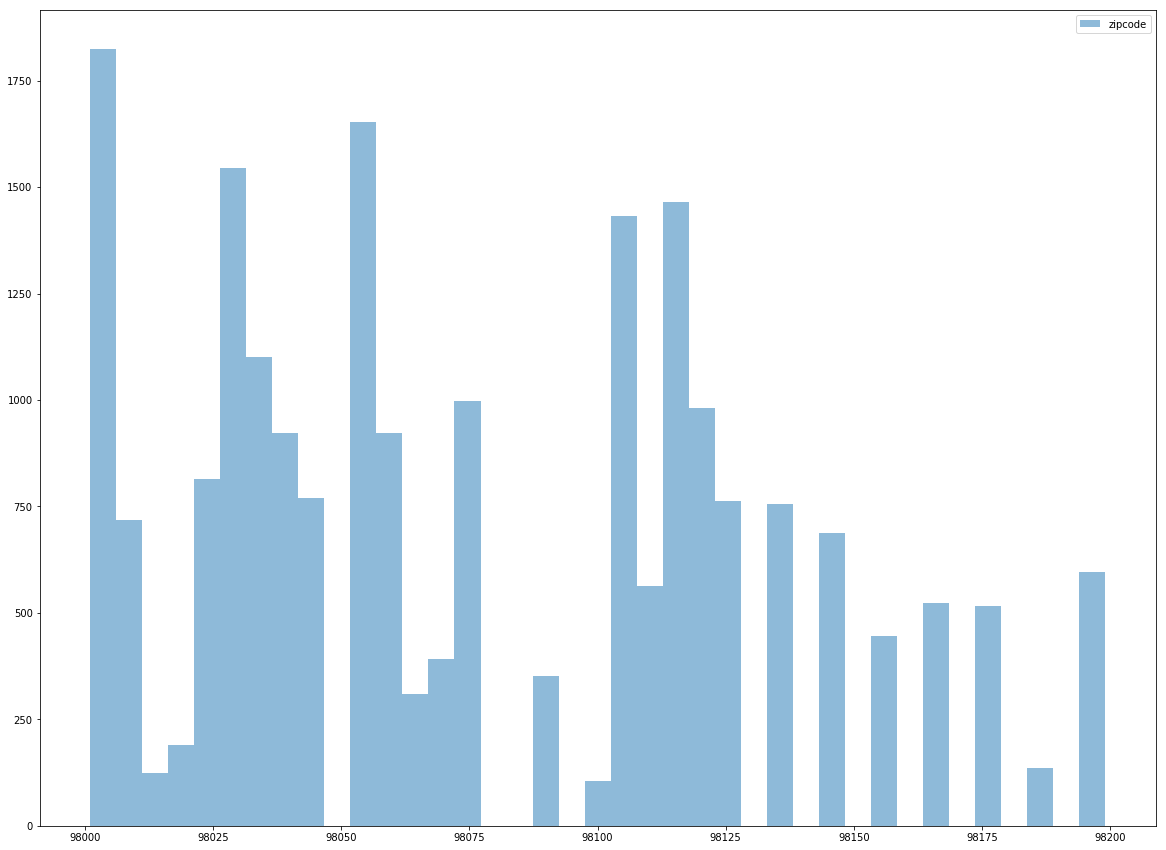

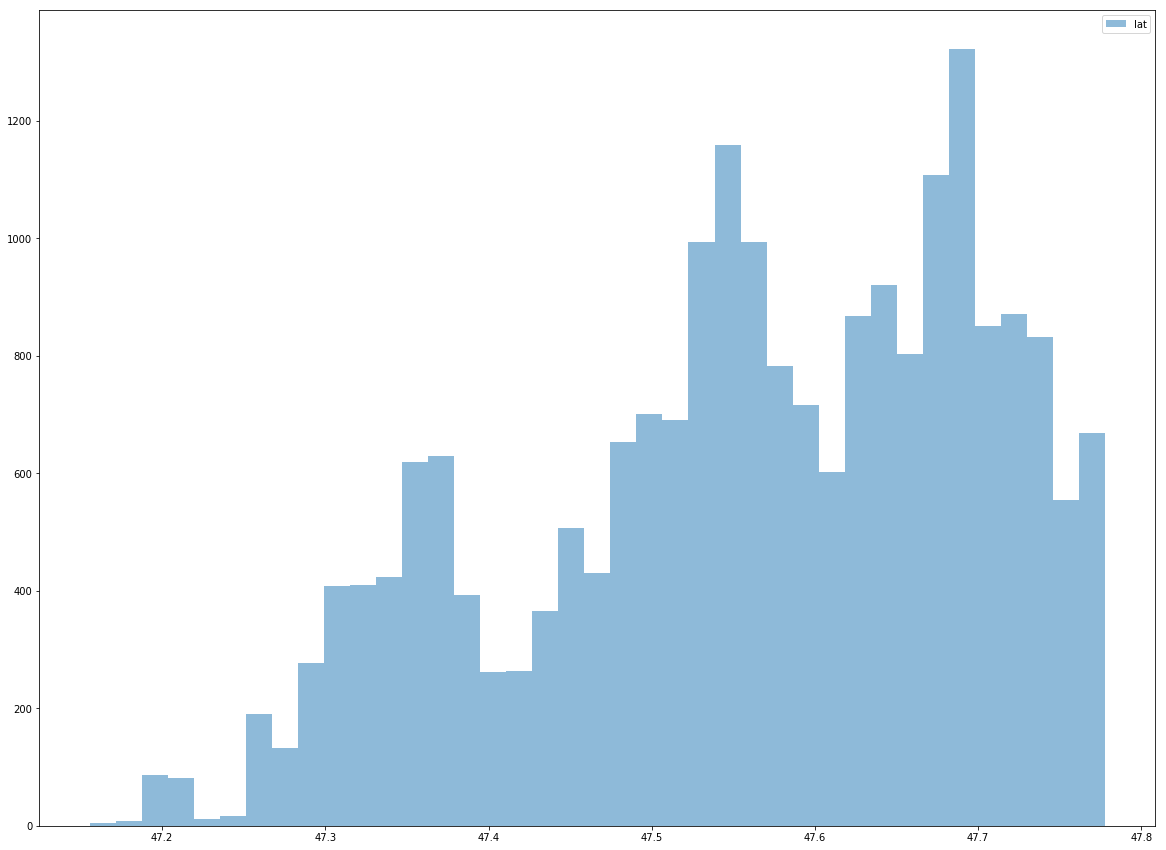

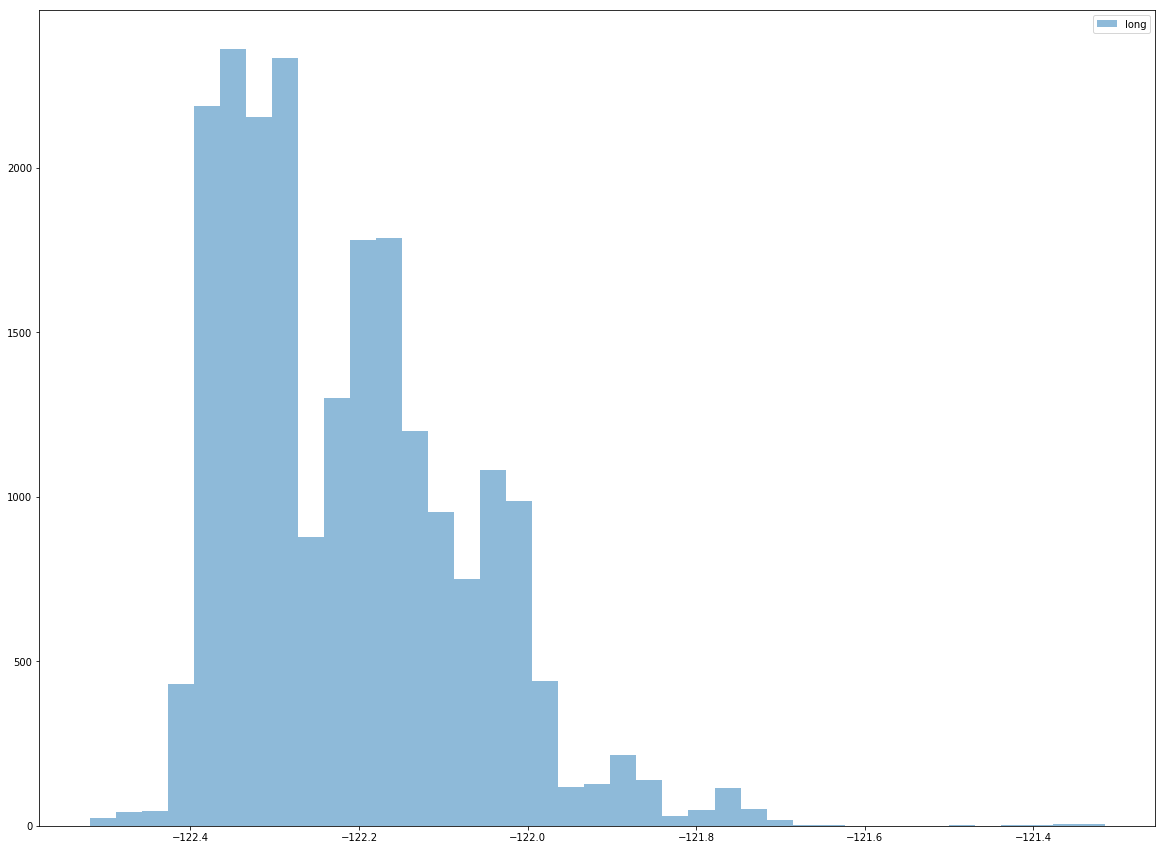

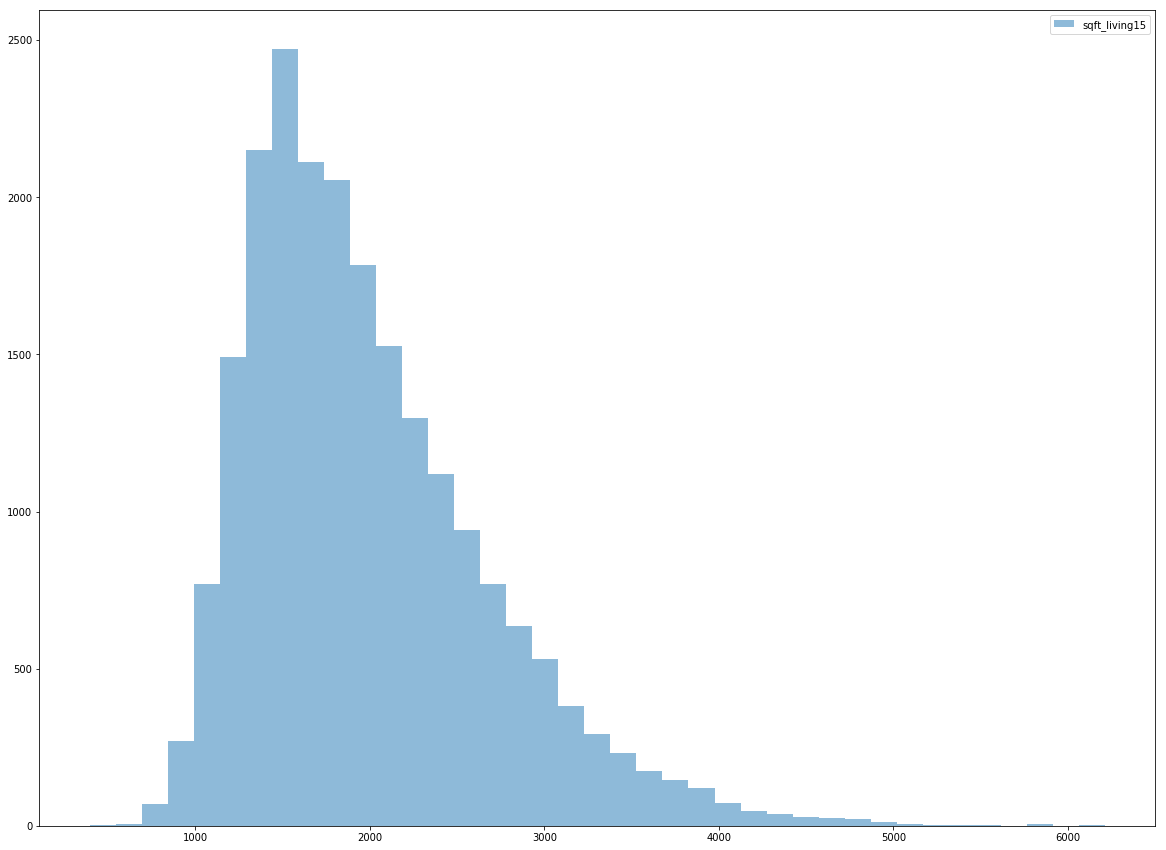

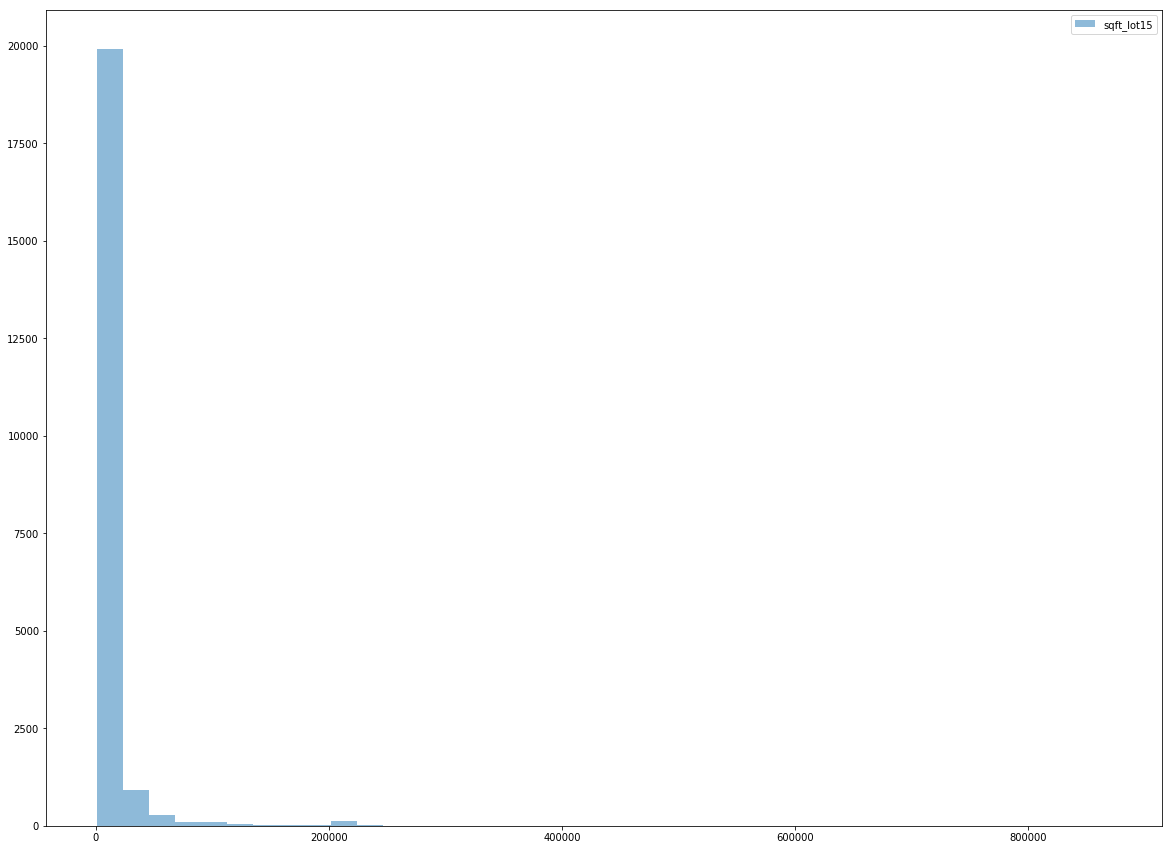

*********************************************************************************


In [343]:
#Look at the individual feature-distribution
quant_attrib_hist_plot(df)

* With above 2 steps, of looking at the general feature-summary, along with the individual distributions for each.It appears that the features: 'id' and 'date' are not too useful (for example if it was thought in terms of housing price prediction, that the date would have been helpful, that might not be the case as another feature: 'yr_built' seems to capture any "age" related aspect, it is also not otherwise clear that the 'date' can have any predictive effect) 
* Another feature, worth looking at, is a "numeric" looking, a possible "high-cardinality" feature 'zipcode', but as it appears to come from a homogeneous (nearby districts of a region, with just 70 unique instances) and also can be treated as "ordinal" (otherwise making use of oneshot/get_dummies encoding for the same, would unnecessarily explode the number of feature-set and given the "ordinality" (like starting with 98000 & sequentially reaching a high of 98200. Models can take in the patterns, this feature has to convey.Additionally, with 'lat', 'long' features (indicating the lattitude & longitude ranges) model has sufficent locational pattern to learn from.

In [344]:
#Now get the p-value summary of features and get the list of features, which you can remove
#i.e. the ones which have p-value > α (0.05 being default here)
#Below removing the dependent variable:'price' and features: 'date', 'id' and a newly formed feature: 'zp', 
#based on a describe().T activity above.
can_drop_feature = get_p_value_feature_drop_list(df, dep_var='price', user_exclude_list=['price','date', 'id','zp'])
print(can_drop_feature)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     2960.
Date:                Sun, 14 Jul 2019   Prob (F-statistic):               0.00
Time:                        20:25:16   Log-Likelihood:            -2.9460e+05
No. Observations:               21613   AIC:                         5.892e+05
Df Residuals:                   21595   BIC:                         5.894e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       6.69e+06   2.93e+06      2.282

* Above give the 'floors' feature with only "very slightly" higher than 0.05, which we can consider only after some more iterations...will *not remove it* just yet, will have to look into the correalation-matrix as well.

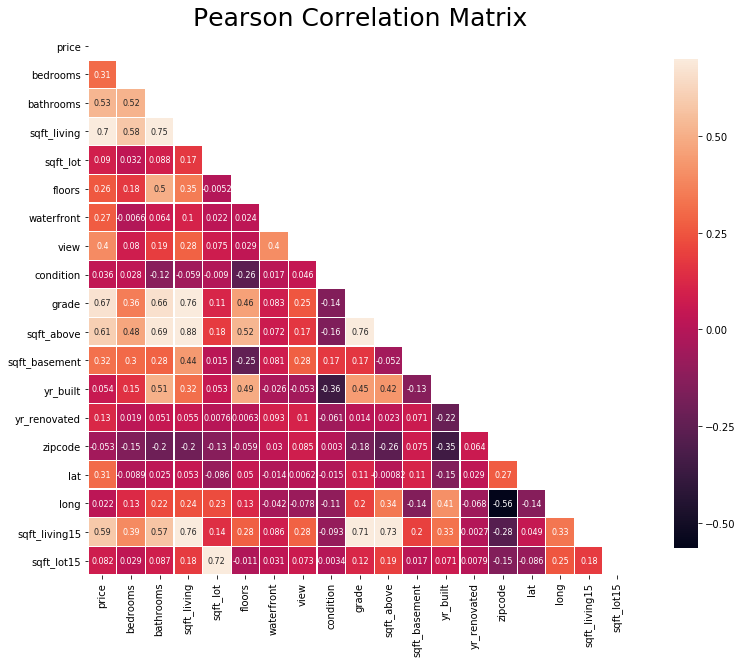

In [345]:
#Also look at the correlation matrix below
plot_correlation_heatmap(df, user_exclude_list=['date', 'id','zp'])

## Step 4

Build a linear regression model to predict the house prices

* To get the linear regession model, we try to follow the forward-selection method here, for which we would make use of the above correalation matrix.Where a feature-by-feature inclusion (one at a time) be made based on the sorted-absolute (highest to lowest) correlation value for features w.r.t. the dependent variable.
* Followoing "get_sorted_corr_list" is written for getting such sorted list of features.

In [346]:
#To get the linear regession model, we try to follow the forward-selection method here.
sorted_lst = get_sorted_corr_list(df, dep_var='price', user_exclude_list=['date', 'id','zp'], ascending=False)
print (sorted_lst)

['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built', 'zipcode', 'condition', 'long']


* Starting with including 'sqft_living', and so on in the next steps (while looking at the %rmse & r^2 during each step)..We will do the train gtest with simple train/test split first.Afyter concluding thru this method on the optimal features.We will move to k-fold cross validation to arrive at a range-estimate of scores.

In [347]:
X=df.drop(['price','date', 'id','zp'],axis=1)
Y=df[['price']]

In [348]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=1)

In [349]:
features = ['sqft_living']
m1=LinearRegression()
m1.fit(Xtrain[features],ytrain)
ypred=m1.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m1.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    278486.730962
dtype: float64
% rmse_test: price    51.035628
dtype: float64
R^2 test: 0.5030774643470592


In [350]:
m2=LinearRegression()
features = ['sqft_living', 'grade' ]
m2.fit(Xtrain[features],ytrain)
ypred=m2.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m2.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    268313.105622
dtype: float64
% rmse_test: price    49.171204
dtype: float64
R^2 test: 0.5387212476176135
Adjusted R^2 test: 0.5386500845888597


* we see that in the process of moving from just single 'sqft_living' to two: 'sqft_living', 'grade' the mode-%-rmse reduces(51.03%->49.17%) and r^2-score increases(50.3%->53.8%)
* we will continue with this iteration to find any anomaly in this process.
* This process is being done manually at this time, but will convert this to a routine later, with a corresponsing populating of an eaval-table.

In [351]:
features = ['sqft_living', 'grade', 'sqft_above' ]
m3=LinearRegression()
m3.fit(Xtrain[features],ytrain)
ypred=m3.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m3.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    266380.647195
dtype: float64
% rmse_test: price    48.81706
dtype: float64
R^2 test: 0.5453418110026818
Adjusted R^2 test: 0.5452015060531378


In [352]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15' ]
m4=LinearRegression()
m4.fit(Xtrain[features],ytrain)
ypred=m4.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m4.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    266051.667429
dtype: float64
% rmse_test: price    48.756771
dtype: float64
R^2 test: 0.5464641221395677
Adjusted R^2 test: 0.5462541518257434


In [353]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms' ]
m5=LinearRegression()
m5.fit(Xtrain[features],ytrain)
ypred=m5.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m5.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    265366.704344
dtype: float64
% rmse_test: price    48.631245
dtype: float64
R^2 test: 0.5487964167505726
Adjusted R^2 test: 0.5485178530319434


In [354]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view' ]
m6=LinearRegression()
m6.fit(Xtrain[features],ytrain)
ypred=m6.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m6.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    255559.756739
dtype: float64
% rmse_test: price    46.834018
dtype: float64
R^2 test: 0.5815297288824468
Adjusted R^2 test: 0.5812067354654064


In [355]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement' ]
m7=LinearRegression()
m7.fit(Xtrain[features],ytrain)
ypred=m7.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m7.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    255559.756739
dtype: float64
% rmse_test: price    46.834018
dtype: float64
R^2 test: 0.5815297288824433
Adjusted R^2 test: 0.5811420769406948


In [356]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms']
m8=LinearRegression()
m8.fit(Xtrain[features],ytrain)
ypred=m8.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m8.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    254019.006181
dtype: float64
% rmse_test: price    46.551659
dtype: float64
R^2 test: 0.5865603699527449
Adjusted R^2 test: 0.586113477208716


In [357]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat']
m10=LinearRegression()
m10.fit(Xtrain[features],ytrain)
ypred=m10.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m10.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    239135.502958
dtype: float64
% rmse_test: price    43.824101
dtype: float64
R^2 test: 0.6335895982536197
Adjusted R^2 test: 0.6331368904213462


In [358]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront']
m11=LinearRegression()
m11.fit(Xtrain[features],ytrain)
ypred=m11.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m11.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    233968.541586
dtype: float64
% rmse_test: price    42.877201
dtype: float64
R^2 test: 0.6492524758466041
Adjusted R^2 test: 0.6487648750252601


In [359]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront', 'floors']
m12=LinearRegression()
m12.fit(Xtrain[features],ytrain)
ypred=m12.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m12.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    233535.76012
dtype: float64
% rmse_test: price    42.797889
dtype: float64
R^2 test: 0.6505488606836347
Adjusted R^2 test: 0.650009001052372


In [360]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront', 'floors', 'yr_renovated']
m13=LinearRegression()
m13.fit(Xtrain[features],ytrain)
ypred=m13.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m13.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    232497.09219
dtype: float64
% rmse_test: price    42.607542
dtype: float64
R^2 test: 0.6536503688832145
Adjusted R^2 test: 0.6530617029465203


In [361]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot']
m14=LinearRegression()
m14.fit(Xtrain[features],ytrain)
ypred=m14.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m14.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    232414.302752
dtype: float64
% rmse_test: price    42.59237
dtype: float64
R^2 test: 0.6538969869012847
Adjusted R^2 test: 0.6532551639748152


In [362]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15']
m15=LinearRegression()
m15.fit(Xtrain[features],ytrain)
ypred=m15.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m15.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    232077.857087
dtype: float64
% rmse_test: price    42.530713
dtype: float64
R^2 test: 0.6548983071611695
Adjusted R^2 test: 0.6542049034506742


In [363]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat',
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built']
m16=LinearRegression()
m16.fit(Xtrain[features],ytrain)
ypred=m16.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m16.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    222581.649474
dtype: float64
% rmse_test: price    40.790433
dtype: float64
R^2 test: 0.6825623822908935
Adjusted R^2 test: 0.6818753940936563


In [364]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built', 'zipcode']
m17=LinearRegression()
m17.fit(Xtrain[features],ytrain)
ypred=m17.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m17.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    221680.904563
dtype: float64
% rmse_test: price    40.625362
dtype: float64
R^2 test: 0.6851264010874192
Adjusted R^2 test: 0.6843961747448576


In [365]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built', 'zipcode', 'condition']
m18=LinearRegression()
m18.fit(Xtrain[features],ytrain)
ypred=m18.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m18.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    221176.719556
dtype: float64
% rmse_test: price    40.532964
dtype: float64
R^2 test: 0.6865570521783639
Adjusted R^2 test: 0.6857815632089583


In [366]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built', 'zipcode', 'condition', 'long']
m19=LinearRegression()
m19.fit(Xtrain[features],ytrain)
ypred=m19.predict(Xtest[features])
rmse_test=np.sqrt(np.mean((ytest-ypred)**2))
#Absolute RMSE
print ("Absolute rmse_test: {}".format(rmse_test))
percent_rmse_test = (rmse_test/np.mean(ytest))*100
#%RMSE
print ("% rmse_test: {}".format(percent_rmse_test))
# R^2
r2_test = m19.score(Xtest[features],ytest)
print ("R^2 test: {}".format(r2_test))
#adjusted-R^2
adj_r2_test = adjustedR2(r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

Absolute rmse_test: price    219788.462924
dtype: float64
% rmse_test: price    40.278552
dtype: float64
R^2 test: 0.6904794689323465
Adjusted R^2 test: 0.6896656970442936


* With these manual steps of including one feature at a time (from the descending-sorted-correlation list of efatures w.r.t. deoendent-variable) we find that R^2 (& the better evaluator: Adj-R^2 for multi-linear regression) both increase monotonically and similarly, the %RMSE too decrease monotonically.Hence there isn't an issue with settling with the final feature-set:

*features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 
            'waterfront', 'floors', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'yr_built', 'zipcode', 'condition', 'long']*

## Step 5
Try to find out important features or create new features to improve the performance for your model.

* With the above train/test split data itself (so as to compare with the similar conditions, the earlier models), we will use the Lasso-regularization to find out where we land.

In [367]:
from sklearn.linear_model import Lasso

In [368]:
Ls=Lasso(alpha=1,normalize=True)

In [369]:
Ls.fit(Xtrain,ytrain)
Ls_pred=Ls.predict(Xtest)
Ls_rmse=np.sqrt(mean_squared_error(ytest,Ls_pred))
Ls_rmse
percent_ls_rmse_test = (Ls_rmse/np.mean(ytest))*100
percent_ls_rmse_test
# R^2
Ls_r2_test = Ls.score(Xtest,ytest)
Ls_r2_test
#adjusted-R^2
adj_r2_test = adjustedR2(Ls_r2_test, Xtest.shape[0],len(features))
print ("Adjusted R^2 test: {}".format(adj_r2_test))

Lasso(alpha=1, copy_X=True, fit_intercept=True, max_iter=1000, normalize=True,
   positive=False, precompute=False, random_state=None, selection='cyclic',
   tol=0.0001, warm_start=False)

219826.46435755273

price    40.285516
dtype: float64

0.6903724274554581

Adjusted R^2 test: 0.6895583741406952


In [370]:
variables=X.columns
variables

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [371]:
Ls.coef_

array([-3.20163314e+04,  3.73005227e+04,  1.43474170e+02,  8.28655340e-02,
        9.42802101e+03,  5.62575996e+05,  5.16236872e+04,  2.65575011e+04,
        9.53187075e+04,  3.26765462e+01,  0.00000000e+00, -2.53539344e+03,
        2.16989448e+01, -5.46334120e+02,  6.13029408e+05, -2.03718853e+05,
        1.90817559e+01, -2.96093131e-01])

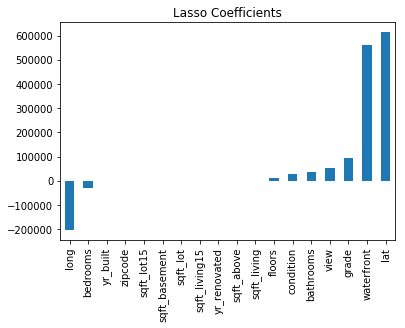

In [372]:
lasso_beta=pd.Series(Ls.coef_,variables).sort_values()
lasso_beta.plot(kind='bar',title='Lasso Coefficients')

* We find that, at least for this train/test split, the Lasso-regularization has at least matched the Adjusted R^2 test to 68.95 from earlier 68.96...while the %rmse was also at least maintained to ~40.28 %....But the main advantage it has, it showed us the feature-importance matrix according to which: 'lat', 'waterfront', 'long', 'grade', 'view', 'bathrooms', 'condition', 'bedrooms' &  'floors' (themselevs) achieve the same 

## Step 6
Use appropriate cross validations techniques to find out the best predictor parameters and best prediction.

* Now we will use the cross validation technique: k-fold one to get a range-estimate of scores

In [373]:
from sklearn import metrics
from sklearn.model_selection import KFold
LR=LinearRegression(normalize=True)
Lasso_R=Lasso(alpha=0.1,normalize=True)

In [374]:
kf=KFold(n_splits=5,shuffle=True,random_state=2)
for model, name in zip([LR,Lasso_R],['LR','Lasso']):
    percent_rmse=[]
    for train,test in kf.split(X,Y):
        Xtrain,Xtest=X.iloc[train,:],X.iloc[test,:]
        Ytrain,Ytest=Y.iloc[train],Y.iloc[test]
        model.fit(Xtrain,Ytrain)
        Y_predict=model.predict(Xtest)
        percent_rmse.append((np.sqrt(metrics.mean_squared_error(Ytest,Y_predict))/np.mean(ytest))*100)
    print(percent_rmse)
    print("Cross_Validated_rmse_score: %0.03f (+/- %0.5f) [%s]" % (np.mean(percent_rmse),np.var(percent_rmse,ddof=1),name)) 

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

...

Lasso(alpha=0.1, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=True, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False)

Lasso(alpha=0.1, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=True, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False)

Lasso(alpha=0.1, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=True, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False)

Lasso(alpha=0.1, copy_X=True, fit_intercept=True, max_iter=1000,
   normalize=True, positive=False, precompute=False, random_state=None,
   selection='cyclic', tol=0.0001, warm_start=False)

[price    36.51576
dtype: float64, price    37.47279
dtype: float64, price    37.283479
dtype: float64, price    38.249821
dtype: float64, price    35.234234
dtype: float64]
Cross_Validated_rmse_score: 36.951 (+/- 1.30162) [Lasso]


# End Of Assignment